<a href="https://colab.research.google.com/github/tetianaboyko3/Python-practice/blob/main/Tetiana_Boiko_11_1_%D0%92%D1%96%D0%B7%D1%83%D0%B0%D0%BB%D1%96%D0%B7%D0%B0%D1%86%D1%96%D1%8F_%D0%B4%D0%B0%D0%BD%D0%B8%D1%85_%D0%B7_Pandas_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнє завдання: Візуалізація даних з Pandas

## Опис завдання
У цьому домашньому завданні ви працюватимете з датасетом про оренду велосипедів `yulu_rental.csv`. Датасет містить інформацію про кількість орендованих велосипедів залежно від погодних умов, сезону та інших факторів.
Набір даних взяти з Kaggle. Посилання на оригінальний [опис](https://www.kaggle.com/datasets/ranitsarkar01/yulu-bike-sharing-data?select=yulu_bike_sharing_dataset.csv).

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів



---
🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.


Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

## Підготовка даних


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Завантаження даних
df = pd.read_csv('drive/MyDrive/Files/yulu_rental.csv')

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Перетворення datetime у правильний формат
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додамо додаткові колонки для аналізу
df['date'] = df.index.date
df['day'] = df.index.day
df['week'] = df.index.isocalendar().week
df['weekday_num'] = df.index.weekday
df['weekday'] = df.index.day_name()
df['year'] = df.index.year
df['month'] = df.index.month
df['hour'] = df.index.hour

## Завдання 0: Перегляд даних
**Завдання:**
Перегляньте дані, їх розмір, та напишіть висновок:
- скільки даних в наборі
- який рівень деталізації мають ці дані, тобто за який період міститься дані в одному рядку даних ?

In [ ]:
df.shape

(10886, 19)

In [ ]:
df.head()

,season,holiday,workingday,weather,temp,atemp,humidity,windspeed,casual,registered,count,date,day,week,weekday_num,weekday,year,month,hour
datetime,,,,,,,,,,,,,,,,,,,
2011-01-01 00:00:00,1,0,0,1,9.84,14.395,81,0.0,3,13,16,2011-01-01,1,52,5,Saturday,2011,1,0
2011-01-01 01:00:00,1,0,0,1,9.02,13.635,80,0.0,8,32,40,2011-01-01,1,52,5,Saturday,2011,1,1
2011-01-01 02:00:00,1,0,0,1,9.02,13.635,80,0.0,5,27,32,2011-01-01,1,52,5,Saturday,2011,1,2
2011-01-01 03:00:00,1,0,0,1,9.84,14.395,75,0.0,3,10,13,2011-01-01,1,52,5,Saturday,2011,1,3
2011-01-01 04:00:00,1,0,0,1,9.84,14.395,75,0.0,0,1,1,2011-01-01,1,52,5,Saturday,2011,1,4


In [ ]:
df.index.min()

Timestamp('2011-01-01 00:00:00')

In [ ]:
df.index.max()

Timestamp('2012-12-19 23:00:00')

✅***Висновок***:
Набір даних містить 10 886 рядків та 19 колонок. Дані мають погодинну деталізацію, тобто кожен рядок відповідає одній годині.Період спостережень охоплює час з 1 січня 2011 року до 31 грудня 2012 року.

## Завдання 1: Базовий лінійний графік

**Завдання:**
1. Згрупуйте дані про кількість орендованих велосипедів (`count`) поденно.
2. Побудуйте з методом `DataFrame.plot()` лінійний графік поденної кількості орендованих велосипедів (`count`) за весь період в даних.
3. Налаштуйте розмір графіка (12x6), додайте заголовок "Динаміка оренди велосипедів" та сітку.
4. Дайте відповіді на питання по цьому графіку. Якщо треба - проведіть додаткові програмні операції для відповідей.

**Питання для інтерпретації:**
1. Як гадаєте, чому графік має "заломи", чим це спричинено і як ви б могли прибрати заломи?
2. Які загальні тенденції ви бачите на графіку?
3. Чи помітні якісь сезонні коливання?
4. Чи є періоди з аномально високими або низькими значеннями і чому на ваш погляд можуть бути ці аномалії?


In [ ]:
# Кількість орендованих велосипедів поденно
daily_count = df['count'].resample ('D').sum()
daily_count

,count
datetime,
2011-01-01,985
2011-01-02,801
2011-01-03,1349
2011-01-04,1562
2011-01-05,1600
...,...
2012-12-15,5047
2012-12-16,3786
2012-12-17,4585


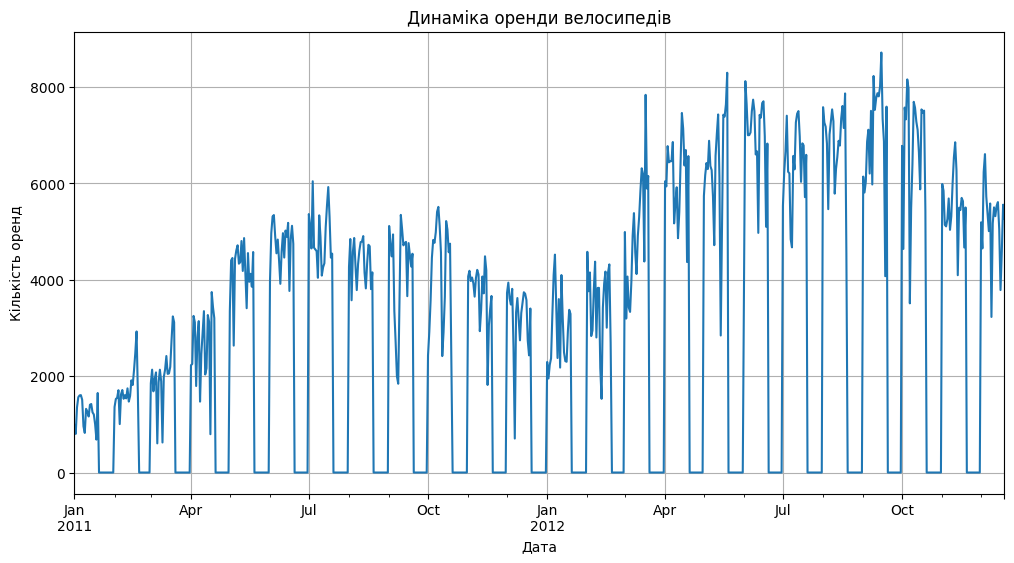

In [ ]:
daily_count.plot(
  kind = 'line',
 # marker = 'o',
  figsize=(12,6),
  title='Динаміка оренди велосипедів',
  xlabel= 'Дата',
  ylabel= 'Кількість оренд',
  grid=True

);

✅**Висновок:**

Поденний графік оренди велосипедів має численні заломи, оскільки дані фіксуються щодня і сильно залежить від дня тижня, погодних умов та святкових днів.

Такі різкі коливання можна зменшити за допомогою згладжування (наприклад, ковзного середнього) або агрегування даних по тижнях чи місяцях.

На графіку спестерігається загальна тенденція до зростання кількості оренд з часом, що може свідчити про зростання популярності сервісу. Також помітні сезонні коливання, характерні для кліматичних умов Індії.

Зниження попиту спостерігається у періоди несприятливої погоди, зокрема під час мусонів або екстремальної спеки.

Окремі аномально високі або низькі значення можуть бути пов'язані зі святами, вихідними днями або незвичними погодними умовами.


## Завдання 2: Аналіз сезонності (Bar Plot)

**Завдання:**
Побудуйте вертикальну стовпчасту діаграму середньої кількості орендованих велосипедів за сезонами(кварталами). Додайте підписи осей і заголовок.

Просунуте доповнення:
1. Позначте квартали не числом, а назвою на візуалізації.
2. Додайте підписи над стовпцями зі значеннями в кожному стовпці.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В який квартал найбільша середня кількість оренди велосипедів?
2. Як ви можете пояснити таку сезонну закономірність?
3. У скільки разів відрізняється оренда між найпопулярнішим та найменш популярним кварталми?

In [ ]:
# Функція мапінгу місяця → сезон Індії
def india_season(month):
    if month in [12, 1, 2]:
        return 1 # Winter
    elif month in [3, 4, 5]:
        return 2 # Summer
    elif month in [6, 7, 8, 9]:
        return 3 # Monsoon
    else:
        return 4 # Post-monsoon

# Створення нової колонки
df['weather_season_india'] = df['month'].apply(india_season)


In [ ]:
df['weather_season_india']


,weather_season_india
datetime,
2011-01-01 00:00:00,1
2011-01-01 01:00:00,1
2011-01-01 02:00:00,1
2011-01-01 03:00:00,1
2011-01-01 04:00:00,1
...,...
2012-12-19 19:00:00,1
2012-12-19 20:00:00,1
2012-12-19 21:00:00,1


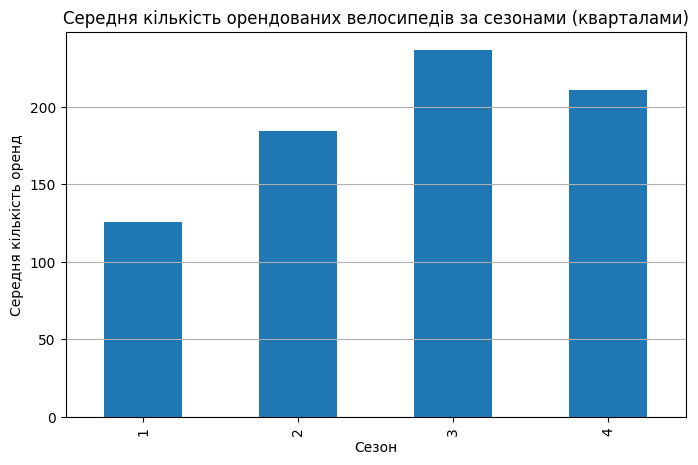

In [ ]:
seasonal_avg_india = (
    df.groupby('weather_season_india')['count'].mean()
)

seasonal_avg_india.plot(
    kind='bar',
    figsize=(8, 5),
    title='Середня кількість орендованих велосипедів за сезонами (кварталами)'
)

plt.xlabel('Сезон')
plt.ylabel('Середня кількість оренд')
plt.grid(axis='y')
plt.show()

✅**Висновок:**

Максимальна середня кількість орендованих велосипедів зафіксована у третьому кварталі (Q3).

Така сезонна динаміка, ймовірно, зумовлена комфортними температурними умовами.
 Хоча Q3 (липень–вересень) припадає на мусонний сезон в Індії, очевидно, що умови цього періоду є більш сприятливими для використання велосипедів, ніж в інші сезони.

## Завдання 3: Динаміка за місяцями (Line Plot)

**Завдання:**
Створіть лінійний графік середньої кількості оренди велосипедів по місяцях (тобто групування в рамках місяця і беремо середню кількість оренд в цей місяць з кількох років). Використайте маркери-кружечки для точок, додайте сітку та пофарбуйте лінію у червоний колір.

Просунуте доповнення:
- додайте аби по осі ОХ поділки були чітко на кожен окремий місяць по одній. Тобто сумарно 12 поділок.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які місяці спостерігається пік та спад оренди?
2. Чи збігається ця закономірність з результатами з попереднього завдання?
3. Як може вплинути клімат на оренду велосипедів протягом року?


In [ ]:
monthly_avg = df.groupby('month')['count'].mean()


In [ ]:
monthly_avg

,count
month,
1,90.366516
2,110.003330
3,148.169811
4,184.160616
5,219.459430
6,242.031798
7,235.325658
8,234.118421
9,233.805281


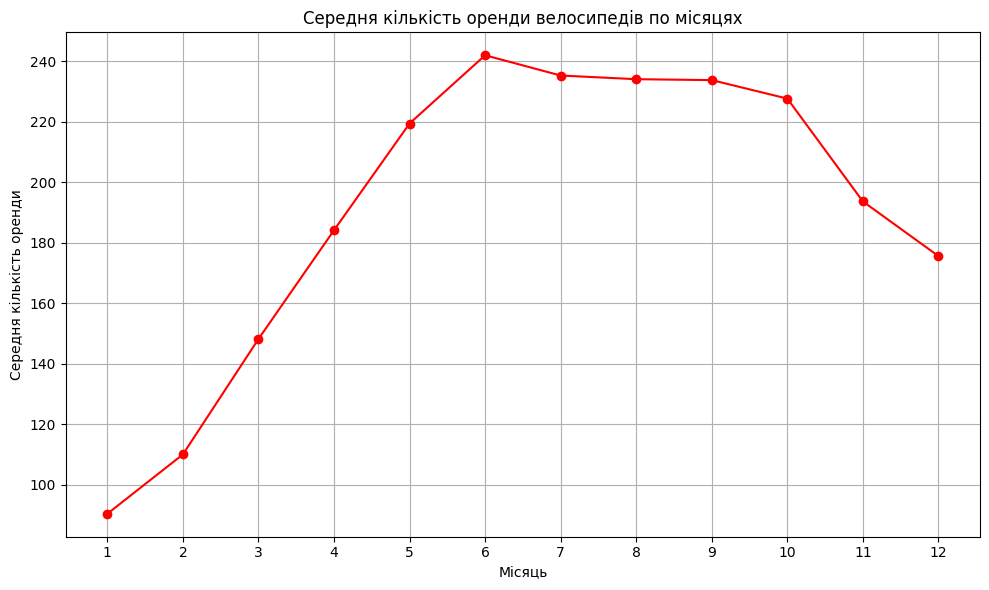

In [ ]:

monthly_avg.plot.line(
    figsize=(10, 6),
    marker='o',
    color='red',
    title='Середня кількість оренди велосипедів по місяцях',
    grid=True
)

plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренди')
plt.xticks(range(1, 13))
plt.tight_layout()
plt.show()

✅**Висновок:**

Максимальна активність оренди велосипедів спостерігається протягом літньо-осіннього періоду (червень–жовтень), тоді як мінімальний попит припадає на зимові місяці (грудень–лютий).

Ця місячна динаміка повністю узгоджується з результатами сезонного аналізу (Завдання 2), підтверджуючи високі показники в теплу пору року (літо та осінь/мусонний сезон).

Кліматичні умови мають прямий вплив: комфортна тепла погода стимулює попит, а низькі температури та зимові опади (холод) обмежують використання велосипедів.

## Завдання 4: Розподіл погодних умов (Pie Chart)

**Завдання:**
1. Побудуйте кругову діаграму з часткою записів за погодними умовами
2. Додайте підписи з відсотками та легенду з описами погоди (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ).
3. Визначте свої відмінні від стандартних кольори для відображення кожної категорії.
4. Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. Яка погода переважає в датасеті?
2. Чи є дні із сильним дощем? Яка їх частка?
3. Як ви думаєте, як погодні умови впливають на попит на оренду велосипедів?

Очікуваний результат:

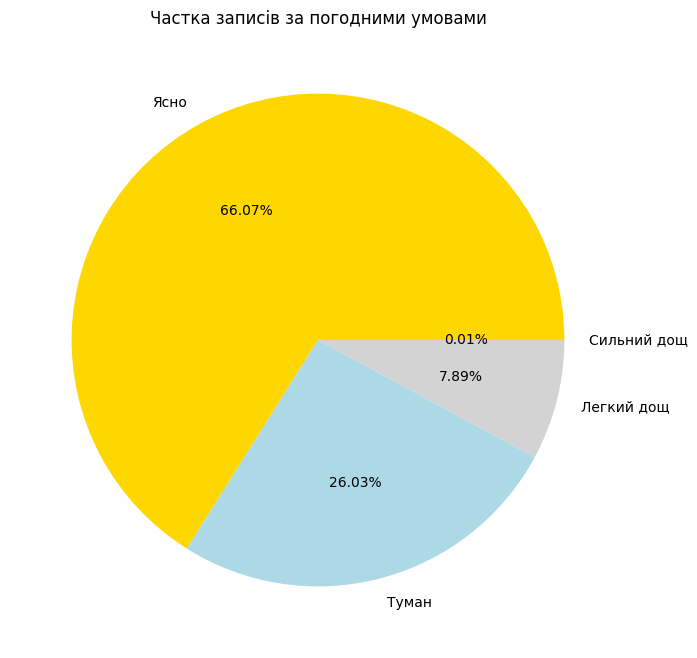

In [ ]:
weather_counts = df['weather'].value_counts().sort_index()

weather_labels = ['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ']

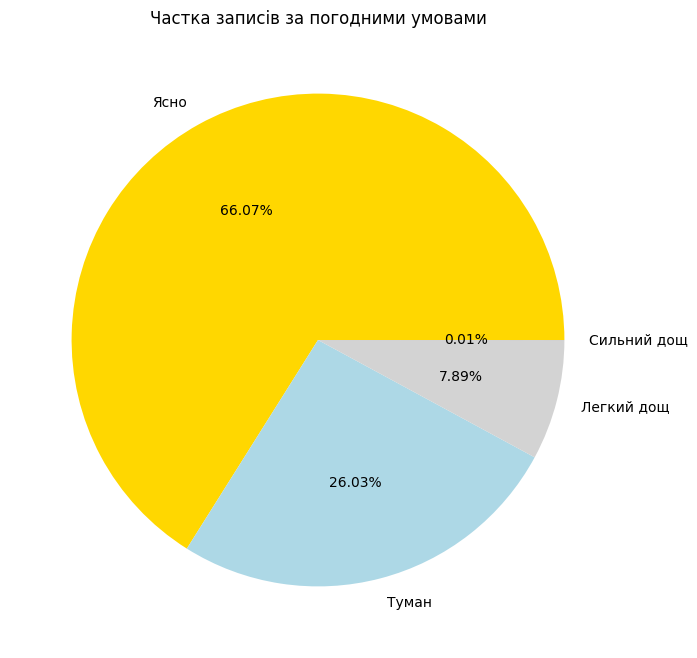

In [ ]:
weather_counts.plot.pie(
    figsize=(8, 8),
    labels=weather_labels,
    autopct='%1.2f%%',
    title='Частка записів за погодними умовами',
    colors=['gold', 'lightblue', 'lightgray', 'darkgray']
)

plt.ylabel('')  # Прибираємо підпис осі Y
plt.show()

✅**Висновок:**

В датасеті переважає ясна погода - 66,07%.

Частка днів із сильним дощем становить 0,01%, такі дні практично відсутні.

Погодні умови значно впливають на оренду велосипедів, зменшуючи попит.

## Завдання 5: Box Plot для аналізу викидів

**Завдання:**
Створіть коробковий графік (box plot) кількості орендованих велосипедів для кожного типу погоди.

Просунуте доповнення:
- Використайте горизонтальну орієнтацію.
- Позначте погодні умови не числом, а назвою на візуалізації.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. При якій погоді найбільший розкид у кількості оренди?
2. Чи є викиди (outliers) в даних? При якій погоді?
3. При якій погоді медіанне значення оренди найвище?

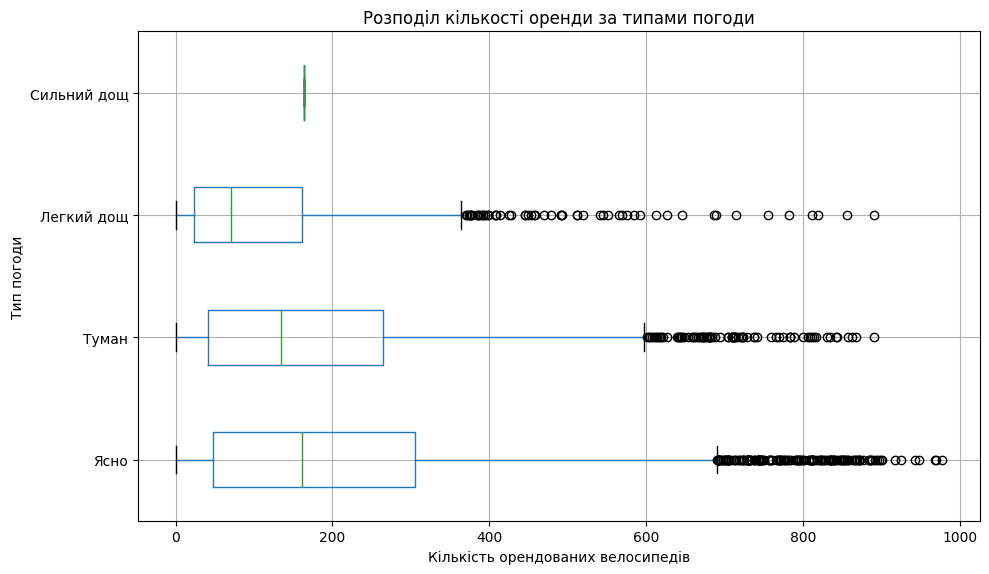

In [ ]:
df.boxplot(
    column='count',
    by='weather',
    figsize=(10, 6),
    vert=False
)

plt.title('Розподіл кількості оренди за типами погоди')
plt.xlabel('Кількість орендованих велосипедів')
plt.ylabel('Тип погоди')
plt.suptitle('')


plt.gca().set_yticklabels(['Ясно', 'Туман', 'Легкий дощ', 'Сильний дощ'])
plt.tight_layout()
plt.show()

✅**Висновок:**

Найбільший діапазон значень (найширший інтерквартильний розмах та загальний розкид) кількості оренди спостерігається саме за ясної погоди, що свідчить про високу варіативність попиту в сприятливих умовах.

На діаграмі присутні аномальні значення (викиди) для всіх категорій погодних умов, які розташовані вище верхнього "вусика" (правого "вусика" у горизонтальному варіанті). Це вказує на окремі дні з надзвичайно високою кількістю оренд, що виходять за межі типового розподілу.

Найвище медіанне значення (лінія всередині "коробки") зафіксовано для категорії "Ясна погода". Це підтверджує, що в середньому ясна погода асоціюється з найбільшим попитом на велосипеди.



## Завдання 6: Кореляція температури та оренди (Scatter Plot)

**Завдання:**
Побудуйте діаграму розсіювання залежності між температурою (`temp`) та загальною кількістю оренди (`count`). Розфарбуйте точки за сезонами, додайте напівпрозорість (alpha=0.6).

**Увага!** За замовченням буде колір

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
- Чи є зв'язок між температурою та кількістю оренди? Який?

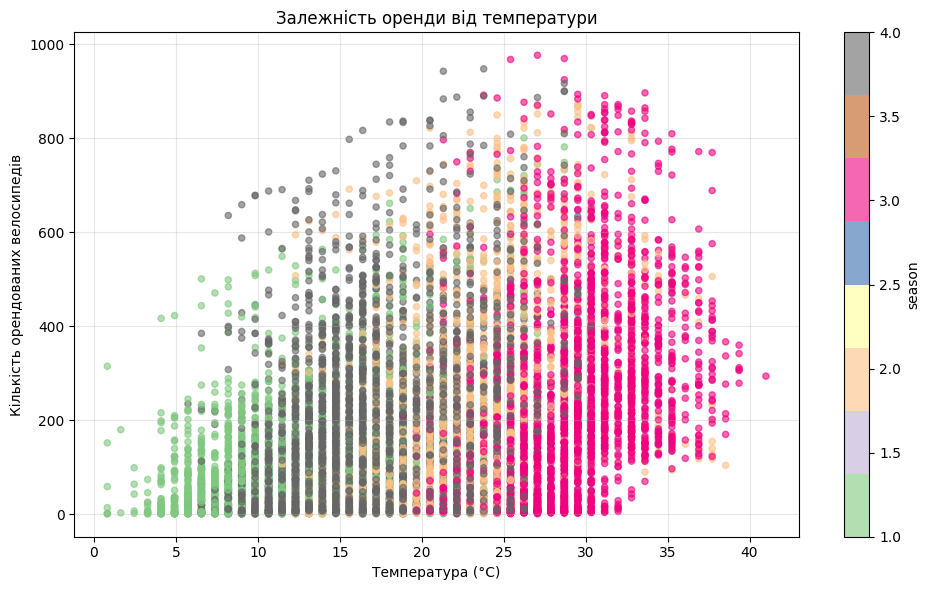

In [ ]:
df.plot.scatter(
    x='temp',
    y='count',
    figsize=(10, 6),
    alpha=0.6,
    c='season',
    cmap='Accent',
    title='Залежність оренди від температури',
    xlabel='Температура (°C)',
    ylabel='Кількість орендованих велосипедів'
)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

✅**Висновок:**

 Є позитивна кореляція - чим вища температура, тим більше оренда



## (Опціонально) Завдання 7: Порівняння користувачів (Stacked Bar Chart)

**Завдання:**
Ми хочемо дізнатись як по дням тижня беруть в середньому в оренду велосипеди випадкові і зареєстровані користувачі.

Створіть стовпчасту діаграму з накопиченням (bar з налаштуванням `stacked=True`), яка показує співвідношення випадкових (`casual`) та зареєстрованих (`registered`) користувачів по днях тижня за кількістю взятих ними велосипедів в оренду в середньому. Використайте різні кольори для типів користувачів.

Дайте відповіді на питання нижче.

**Питання для інтерпретації:**
1. В які дні тижня більше оренд від зареєстрованих користувачів?
2. Як ви можете пояснити таку різницю в поведінці користувачів протягом тижня?

In [ ]:
user_data = df.groupby('weekday')[['casual', 'registered']].mean()

In [ ]:
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

user_data = user_data.reindex(day_order)

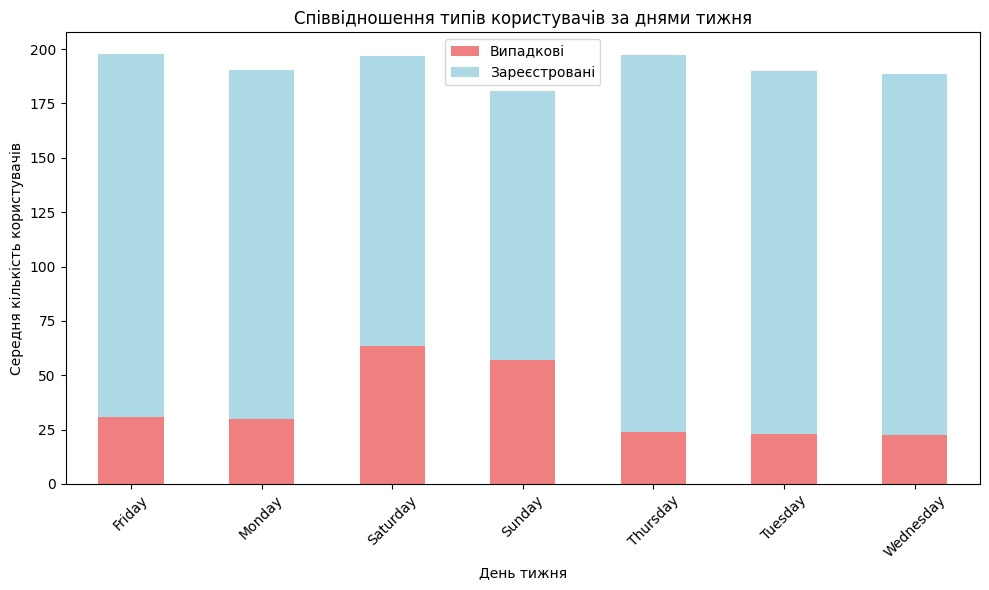

In [ ]:
user_data.plot.bar(
    stacked=True,
    figsize=(10, 6),
    color=['lightcoral', 'lightblue'],
    title='Співвідношення типів користувачів за днями тижня'
)

plt.xlabel('День тижня')
plt.ylabel('Середня кількість користувачів')
plt.legend(['Випадкові', 'Зареєстровані'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

✅Висновок:

1.Домінування зареєстрованих користувачів:
Протягом усього періоду спостереження зареєстровані користувачі стабільно демонструють вищий рівень використання сервісу оренди велосипедів, ніж випадкові користувачі.

2.Пояснення патернів використання:
- Зареєстровані користувачі переважно використовують велосипеди для регулярних, утилітарних поїздок (наприклад, щоденні поїздки на роботу/з роботи).
- Випадкові користувачі, ймовірно, складають сегмент туристів або людей, які користуються послугою нерегулярно, в основному для відпочинку або у вихідні дні, що пояснює їх меншу загальну частку.
